HVSMR-2.0 MSPE-SwinUnterV2 training

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import wandb"|| pip install -q wandb
%matplotlib inline
FOLD_NUMBER = 0

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 24.1 MB/s eta 0:00:00


In [2]:
import glob
import logging
import os
import sys

from pathlib import Path
import shutil
import sys
import tempfile
from abc import ABC, abstractmethod
import wandb
import time
import random

import nibabel as nib
import numpy as np
import monai
from monai.networks.blocks import PatchEmbed
from monai.apps import CrossValidation
from monai.networks.layers import trunc_normal_, Conv, Norm
from monai.config import print_config
from monai.data import CacheDataset, Dataset, create_test_image_3d, decollate_batch, DataLoader, list_data_collate
from monai.handlers import (
    MeanDice,
    MLFlowHandler,
    StatsHandler,
    TensorBoardImageHandler,
    TensorBoardStatsHandler,
)
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.losses import TverskyLoss, DiceLoss
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RandAffined, RandFlipd,
    Rand3DElasticd, RandShiftIntensityd, RandGaussianNoised, AsDiscreted,
    AsDiscrete, RandSpatialCropd, RandCropByPosNegLabeld, SpatialPadd,
    Orientationd, Spacingd, Rand3DElasticd, EnsureTyped, DivisiblePadd,
    CropForegroundd, ScaleIntensityRangePercentilesd
)
from monai.utils import first, set_determinism
from monai.inferers import sliding_window_inference

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import matplotlib.pyplot as plt

print_config()

MONAI version: 1.6.dev2614
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d3272c9ecfbe622fc1c93a16cfdace71d6ac047c
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthe

In [3]:
colab = True
device = torch.device("cuda")
num_workers = 12 # chnage later for gpu transforms

if colab:
    from google.colab import drive, runtime
    drive.mount('/content/drive')
    data_dir = r"/content/drive/MyDrive/HVSMR-2.0/cropped"
    root_dir = r"/content/drive/MyDrive/OVERLAPPING_MSPE_SWIN"
    sys.path.append(root_dir)

Mounted at /content/drive


In [4]:
# Set deterministic training for reproducibility
set_determinism(seed=0)
# torch.backends.cudnn.benchmark = True

In [5]:
train_images = sorted(glob.glob(os.path.join(data_dir, "*_cropped.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(data_dir, "*_cropped_seg.nii.gz")))
train_endpoints = sorted(glob.glob(os.path.join(data_dir, "*_cropped_seg_endpoints.nii.gz")))

dataset_files = [
    {"image": i, "label": l, "endpoint": e}
    for i, l, e in zip(train_images, train_labels, train_endpoints)
]

In [6]:
len(dataset_files) == 60

True

In [7]:
cpu_transforms  = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        Spacingd(keys=["image", "label"], pixdim=(0.75, 0.75, 1.0), mode=("bilinear", "nearest")),
        ScaleIntensityRangePercentilesd(
                        keys=["image"],
                        lower=5,
                        upper=95,
                        b_min=0.0,
                        b_max=1.0,
                        clip=True
                    ),
    ]
)

val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label", "endpoint"]),
        EnsureChannelFirstd(keys=["image", "label", "endpoint"]),
        Orientationd(keys=["image", "label", "endpoint"], axcodes="RAS"),
        CropForegroundd(keys=["image", "label", "endpoint"], source_key="image"),
        Spacingd(
            keys=["image", "label", "endpoint"],
            pixdim=(0.75, 0.75, 1.0),
            mode=("bilinear", "nearest", "nearest")
        ),
         ScaleIntensityRangePercentilesd(
                    keys=["image"],
                    lower=5,
                    upper=95,
                    b_min=0.0,
                    b_max=1.0,
                    clip=True
                ),
        DivisiblePadd(keys=["image", "label", "endpoint"], k=32, mode="constant")
    ]
)

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [8]:
prob = 0.5
# 3D augmentations are faster on GPU
gpu_transforms = Compose([
    EnsureTyped(keys=["image", "label"], device="cpu"),

    # SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),
    DivisiblePadd(keys=["image", "label"], k=32, mode="constant"),

    # NOTE: ONLY FOR VANILLA MODEL
    #RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(96, 96, 96), pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),

    # NOTE: no data aug
    # RandFlipd(keys=["image", "label"], spatial_axis=0, prob=prob),
    # RandFlipd(keys=["image", "label"], spatial_axis=1, prob=prob),
    # RandAffined(keys=["image", "label"], prob=0.5, rotate_range=(0.2, 0.2, 0.2), scale_range=(0.1, 0.1, 0.1), mode=("bilinear", "nearest")),
    # Rand3DElasticd(keys=["image", "label"], prob=prob, sigma_range=(5, 8), magnitude_range=(10, 50), mode=("bilinear", "nearest")),
    # RandShiftIntensityd(keys=["image"], offsets=0.1, prob=prob),
    # RandGaussianNoised(keys=["image"], prob=prob, mean=0.0, std=0.1)
])

In [9]:

class CVDataset(ABC, CacheDataset):
    """
    Base class to generate cross validation datasets dynamically.
    """
    def __init__(
        self,
        data,
        transform,
        cache_num=sys.maxsize,
        cache_rate=1.0,
        num_workers=4,
    ) -> None:
        data = self._split_datalist(datalist=data)
        CacheDataset.__init__(
            self, data, transform, cache_num=cache_num, cache_rate=cache_rate, num_workers=num_workers
        )

    @abstractmethod
    def _split_datalist(self, datalist):
        raise NotImplementedError(f"Subclass {self.__class__.__name__} must implement this method.")

# Set fold
fold_number = FOLD_NUMBER
total_fold_number = 5
folds = list(range(total_fold_number))

cv_splitter = CrossValidation(
    dataset_cls=CVDataset,
    data=dataset_files,
    nfolds=total_fold_number,
    seed=12345
)

train_ds_cpu = cv_splitter.get_dataset(
    folds=folds[0: fold_number] + folds[fold_number + 1:],
    transform=cpu_transforms,
    cache_rate=1.0,
    num_workers=num_workers
)
train_ds = Dataset(data=train_ds_cpu, transform=gpu_transforms)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=list_data_collate
)

val_ds = cv_splitter.get_dataset(
    folds=fold_number,
    transform=val_transforms,
    cache_rate=1.0,
    num_workers=num_workers
)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=num_workers)


Loading dataset: 100%|██████████| 12/12 [00:02<00:00,  4.58it/s]


image shape: torch.Size([128, 128, 96]), label shape: torch.Size([128, 128, 96])


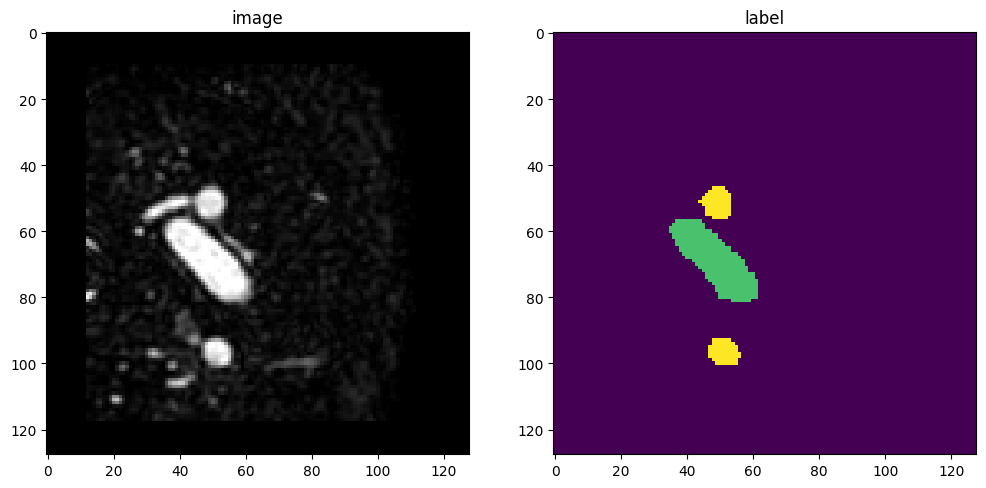

In [10]:
check_data = first(train_loader)
image, label = (check_data["image"][0][0].cpu(), check_data["label"][0][0].cpu())

print(f"image shape: {image.shape}, label shape: {label.shape}")

# H W D -- [136, 175, 125]
D = 80
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, D], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, D])
plt.show()

In [11]:
# See all train scans shapes
for step, batch in enumerate(train_loader):
    print(f"Batch {step}: Image shape = {batch['image'].shape} | Seg shape = {batch['label'].shape}")

Batch 0: Image shape = torch.Size([1, 1, 288, 192, 192]) | Seg shape = torch.Size([1, 1, 288, 192, 192])
Batch 1: Image shape = torch.Size([1, 1, 160, 160, 128]) | Seg shape = torch.Size([1, 1, 160, 160, 128])
Batch 2: Image shape = torch.Size([1, 1, 256, 224, 192]) | Seg shape = torch.Size([1, 1, 256, 224, 192])
Batch 3: Image shape = torch.Size([1, 1, 160, 128, 128]) | Seg shape = torch.Size([1, 1, 160, 128, 128])
Batch 4: Image shape = torch.Size([1, 1, 160, 128, 96]) | Seg shape = torch.Size([1, 1, 160, 128, 96])
Batch 5: Image shape = torch.Size([1, 1, 128, 128, 128]) | Seg shape = torch.Size([1, 1, 128, 128, 128])
Batch 6: Image shape = torch.Size([1, 1, 192, 160, 160]) | Seg shape = torch.Size([1, 1, 192, 160, 160])
Batch 7: Image shape = torch.Size([1, 1, 224, 160, 224]) | Seg shape = torch.Size([1, 1, 224, 160, 224])
Batch 8: Image shape = torch.Size([1, 1, 192, 128, 192]) | Seg shape = torch.Size([1, 1, 192, 128, 192])
Batch 9: Image shape = torch.Size([1, 1, 192, 128, 160]) 

In [12]:
from mspe_overlapping import MSPEPatchEmbedSwin, DEFAULT_RESOLUTIONS_SwinUNETRv2, DEFAULT_K, mspe_swin_forward
FEATURE_SIZE = 24
DEFAULT_RESOLUTIONS_SwinUNETRv2 = [96, 128, 160, 192, 224, 256, 288] # HVSMR-2.0
K = DEFAULT_K

# MSPE-SWIN embedding block
customPatchEmbeddingBlock = MSPEPatchEmbedSwin(patch_size=2, in_chans=1,
                                        embed_dim=FEATURE_SIZE, norm_layer=nn.LayerNorm,
                                        resolutions=DEFAULT_RESOLUTIONS_SwinUNETRv2,
                                        spatial_dims=3, K=DEFAULT_K)

print(DEFAULT_RESOLUTIONS_SwinUNETRv2, '\n', customPatchEmbeddingBlock)

model = monai.networks.nets.SwinUNETR(
    in_channels=1,
    out_channels=9,
    spatial_dims=3,
    feature_size=FEATURE_SIZE,
    use_v2=True
).to(device)

model.swinViT.patch_embed = customPatchEmbeddingBlock.to(device)

# k layers weights before train
initial_mspe_state = copy.deepcopy(model.swinViT.patch_embed.state_dict())

[96, 128, 160, 192, 224, 256, 288] 
 MSPEPatchEmbedSwin(
  spatial_dims=3, patch_size=(2, 2, 2), in_chans=1, embed_dim=24, K=2, kernel_sizes=[(2, 2, 2), (4, 4, 4)], resolutions=[96, 128, 160, 192, 224, 256, 288]
  (norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (patch_kernels): ModuleList(
    (0): Conv3d(1, 24, kernel_size=(2, 2, 2), stride=(2, 2, 2))
    (1): Conv3d(1, 24, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
  )
)


In [13]:
lr = 3e-4
wd = 1e-5
loss_alpha, loss_beta = 0.3, 0.7

loss_function = TverskyLoss(to_onehot_y=True, softmax=True, alpha=loss_alpha, beta=loss_beta)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=10)
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean")
scaler = GradScaler()

/tmp/ipykernel_1040/3949963100.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [14]:
max_epochs = 150
val_interval = 2
best_metric = -1
best_hd95 = 1000
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=9)])
post_label = Compose([AsDiscrete(to_onehot=9)])
early_stopping_patience = 50  # stop train run if no improvement
epochs_no_improve = 0
# model.swinViT.use_checkpoint = True # More VRAM, but faster

wandb.init(
    project="HVSMR-MSPE_SWIN",
    name=f"OVERLAP_MSPE_K2-SWIN-VOLUME_FOLD_{fold_number}_AUG_0",
    config={
        "max_epochs": max_epochs,
        "val_interval": val_interval,
        "batch_size": 1,
        'feature_size': FEATURE_SIZE,
        "training_strategy": "full_volume_DivisiblePadd_k32",
        "inference_strategy": "full_volume",
        "mspe_resolutions": DEFAULT_RESOLUTIONS_SwinUNETRv2,
        "mspe_K": DEFAULT_K,
        "gradient_checkpointing": False,
        "optional_zones_substraction": False,

        "learning_rate": lr,
        "weight_decay": wd,
        "optimizer": "AdamW",

        "loss_type": "TverskyLoss",
        "loss_alpha": loss_alpha,
        "loss_beta": loss_beta,

        "fold_number": fold_number,
        "total_fold_number": total_fold_number,
        "prob_transforms": prob,

        "early_stopping_patience": early_stopping_patience,
    },
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: xelacsnol (xelacsnol-no-2-pencil) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [15]:
# WHOLE-IMAGE INFERENCE
substract_endpoints = False

total_start = time.time()
for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )

        optimizer.zero_grad()
        total_loss = 0.0

        for k in range(K):
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = mspe_swin_forward(model, inputs, func_idx=k)
                loss = loss_function(outputs, labels) / K

            scaler.scale(loss).backward()
            total_loss += loss.item() * K

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += total_loss

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    epoch_time_sec = time.time() - epoch_start
    print(f"time per epoch: {epoch_time_sec:.2f} s")

    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
    "train/epoch_loss": epoch_loss,
    "lr": current_lr,
    "epoch": epoch + 1,
    "train/time_per_epoch": epoch_time_sec,
    "amp/scaler_scale": scaler.get_scale(),
    })

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels, val_endpoints = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                    val_data["endpoint"].to(device)
                )

                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    val_outputs = model(val_inputs)

                # deocllate and convert to one-hot
                val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]
                val_endpoints_list = [post_label(i) for i in decollate_batch(val_endpoints)]

                # NOTE: optional zones are not substracted
                if substract_endpoints:
                    for i in range(len(val_outputs_list)):
                        val_endpoints_list[i][0, ...] = 0
                        val_outputs_list[i] = torch.clamp(val_outputs_list[i] - val_endpoints_list[i], min=0)
                        val_labels_list[i] = torch.clamp(val_labels_list[i] - val_endpoints_list[i], min=0)

                dice_metric(y_pred=val_outputs_list, y=val_labels_list)

            # Metric
            metric = dice_metric.aggregate().item()
            dice_metric.reset()

            scheduler.step(metric)

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                epochs_no_improve = 0
                torch.save(model.state_dict(), os.path.join(root_dir, f"best_metric_MSPE-SWIN_fold{fold_number}_A0.pth"))
                print("saved new best metric model")
                print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.3f}", '\n'
                f"best mean dice: {best_metric:.3f} "
                f"at epoch: {best_metric_epoch}"
                )
            else:
                epochs_no_improve += val_interval

            wandb.log({
            "Dice": metric,
            "epoch": epoch + 1,
            })

            if epochs_no_improve >= early_stopping_patience: # early stop
                print(f"Early stopping triggered at epoch {epoch + 1}. No improvement for {early_stopping_patience} epochs.")
                wandb.log({"early_stop_epoch": epoch + 1})
                break

total_time = time.time() - total_start
print(f"total epochs: {max_epochs}, total training time: {total_time / 60:.2f} min, average time per epoch: {total_time / max_epochs:.2f} s")
wandb.finish()

----------
epoch 1/150
epoch 1 average loss: 1.8371
time per epoch: 37.80 s
----------
epoch 2/150
epoch 2 average loss: 1.7391
time per epoch: 35.83 s
saved new best metric model
current epoch: 2 current mean dice: 0.120 
best mean dice: 0.120 at epoch: 2
----------
epoch 3/150
epoch 3 average loss: 1.6499
time per epoch: 35.87 s
----------
epoch 4/150
epoch 4 average loss: 1.5553
time per epoch: 35.90 s
saved new best metric model
current epoch: 4 current mean dice: 0.185 
best mean dice: 0.185 at epoch: 4
----------
epoch 5/150
epoch 5 average loss: 1.4890
time per epoch: 35.90 s
----------
epoch 6/150
epoch 6 average loss: 1.4368
time per epoch: 35.86 s
saved new best metric model
current epoch: 6 current mean dice: 0.216 
best mean dice: 0.216 at epoch: 6
----------
epoch 7/150
epoch 7 average loss: 1.4027
time per epoch: 35.94 s
----------
epoch 8/150
epoch 8 average loss: 1.3492
time per epoch: 35.86 s
saved new best metric model
current epoch: 8 current mean dice: 0.239 
best m

Dice,▁▂▂▂▃▄▄▅▅▆▇▇▇█▇█▇███████████████████████
amp/scaler_scale,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃█
early_stop_epoch,▁
epoch,▁▁▁▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇██
lr,█████████████████████████████▃▃▃▃▃▃▃▃▁▁▁
train/epoch_loss,█▇▇▆▆▆▅▅▄▄▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/time_per_epoch,█▁▁▁▁▁▁▁▁▂▁▁▂▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁
Dice,0.65219
amp/scaler_scale,131072
early_stop_epoch,88
epoch,88


In [16]:
print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")

train completed, best_metric: 0.6847 at epoch: 38


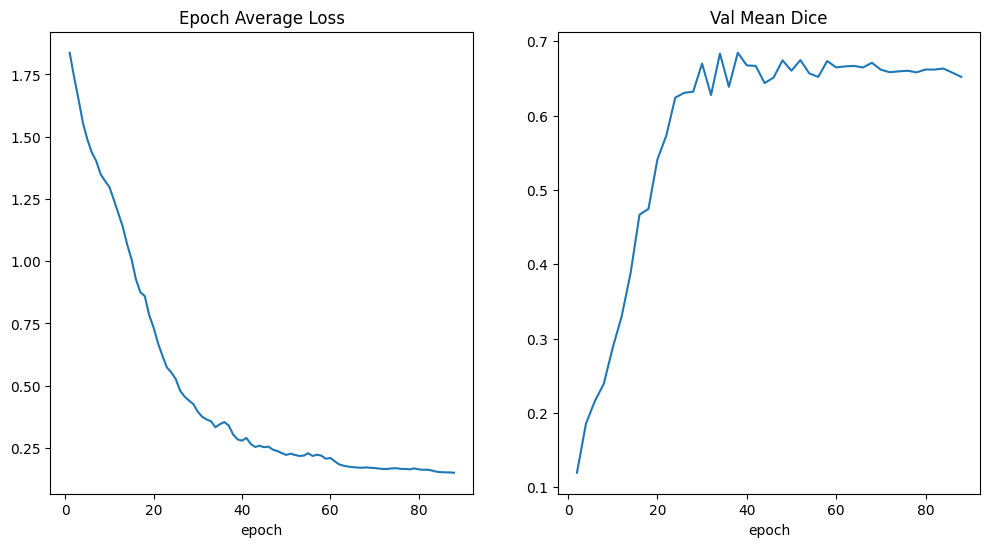

In [17]:
# Plot the loss and metric
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

In [18]:
# Compute HD95 for the final model

model.load_state_dict(torch.load(os.path.join(root_dir, f"best_metric_MSPE-SWIN_fold{fold_number}_A0.pth"), weights_only=True))
model.eval()

hd95_per_class = HausdorffDistanceMetric(
    include_background=False, percentile=95, reduction="mean_batch")
dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")

substract_endpoints_eval = False

with torch.no_grad():
    for val_data in val_loader:
        val_inputs, val_labels, val_endpoints = (
            val_data["image"].to(device),
            val_data["label"].to(device),
            val_data["endpoint"].to(device)
        )

        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16):
            val_outputs = model(val_data["image"].to(device))

        val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
        val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]
        val_endpoints_list = [post_label(i) for i in decollate_batch(val_endpoints)]

        if substract_endpoints_eval:
            for i in range(len(val_outputs_list)):
                val_endpoints_list[i][0, ...] = 0
                val_outputs_list[i] = torch.clamp(val_outputs_list[i] - val_endpoints_list[i], min=0)
                val_labels_list[i] = torch.clamp(val_labels_list[i] - val_endpoints_list[i], min=0)

        # Move to cpu
        val_outputs_list_cpu = [v.cpu() for v in val_outputs_list]
        val_labels_list_cpu = [v.cpu() for v in val_labels_list]

        hd95_per_class(y_pred=val_outputs_list_cpu, y=val_labels_list_cpu)
        dice_per_class(y_pred=val_outputs_list_cpu, y=val_labels_list_cpu)

hd95_vals = hd95_per_class.aggregate()
dice_vals = dice_per_class.aggregate()
hd95_per_class.reset()
dice_per_class.reset()

num_classes = hd95_vals.shape[0]

print(f"{'Class':>8} | {'Dice':>8} | {'HD95':>10}")
print('-' * 32)
for c in range(num_classes):
    d = dice_vals[c].item()
    h = hd95_vals[c].item()
    print(f"{c+1:>8} | {d:>8.4f} | {h:>10.2f}")

mean_dice = dice_vals.nanmean().item()
mean_hd95 = hd95_vals.nanmean().item()
print('-' * 32)
print(f"{'Mean':>8} | {mean_dice:>8.4f} | {mean_hd95:>10.2f}")
print(f"\nFinal model — Mean Dice: {mean_dice:.4f}, Mean HD95: {mean_hd95:.2f}")


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 1 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages

   Class |     Dice |       HD95
--------------------------------
       1 |   0.7529 |      21.47
       2 |   0.7092 |      15.51
       3 |   0.6946 |      16.46
       4 |   0.6128 |      21.88
       5 |   0.8102 |      18.09
       6 |   0.6227 |      19.64
       7 |   0.6580 |      17.67
       8 |   0.6202 |      33.89
--------------------------------
    Mean |   0.6851 |      20.58

Final model — Mean Dice: 0.6851, Mean HD95: 20.58


Kernel Index | L2 Dist | Cosine Sim | Max Diff
-------------------------------------------------------
Kernel K=0    | 0.1994  | 0.8460     | 0.0458
Kernel K=1    | 0.3806  | 0.9080     | 0.0323


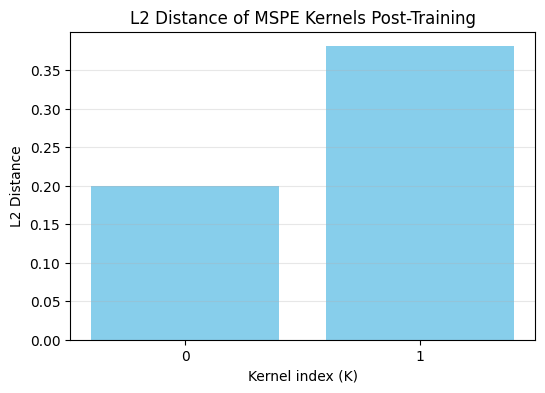

In [19]:
# get final k weights after training
final_mspe_state = model.swinViT.patch_embed.state_dict()

metrics = {
    'l2_distance': [],
    'cosine_sim': [],
    'max_diff': []
}

for k in range(DEFAULT_K):
    # extract weights for the k-th convolution kernel
    w_init = initial_mspe_state[f'patch_kernels.{k}.weight'].flatten()
    w_final = final_mspe_state[f'patch_kernels.{k}.weight'].flatten()

    # L2 dist
    l2_dist = torch.norm(w_final - w_init, p=2).item()

    # cosine similarity
    cos_sim = F.cosine_similarity(w_final.unsqueeze(0), w_init.unsqueeze(0)).item()

    # max absolute diffrence
    max_diff = torch.max(torch.abs(w_final - w_init)).item()

    metrics['l2_distance'].append(l2_dist)
    metrics['cosine_sim'].append(cos_sim)
    metrics['max_diff'].append(max_diff)

print("Kernel Index | L2 Dist | Cosine Sim | Max Diff")
print("-" * 55)
for k in range(DEFAULT_K):
    print(f"Kernel K={k:<4} | {metrics['l2_distance'][k]:.4f}  | {metrics['cosine_sim'][k]:.4f}     | {metrics['max_diff'][k]:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(range(DEFAULT_K), metrics['l2_distance'], color='skyblue')
plt.xlabel('Kernel index (K)')
plt.ylabel('L2 Distance')
plt.title('L2 Distance of MSPE Kernels Post-Training')
plt.xticks(range(DEFAULT_K))
plt.grid(axis='y', alpha=0.3)
plt.show()


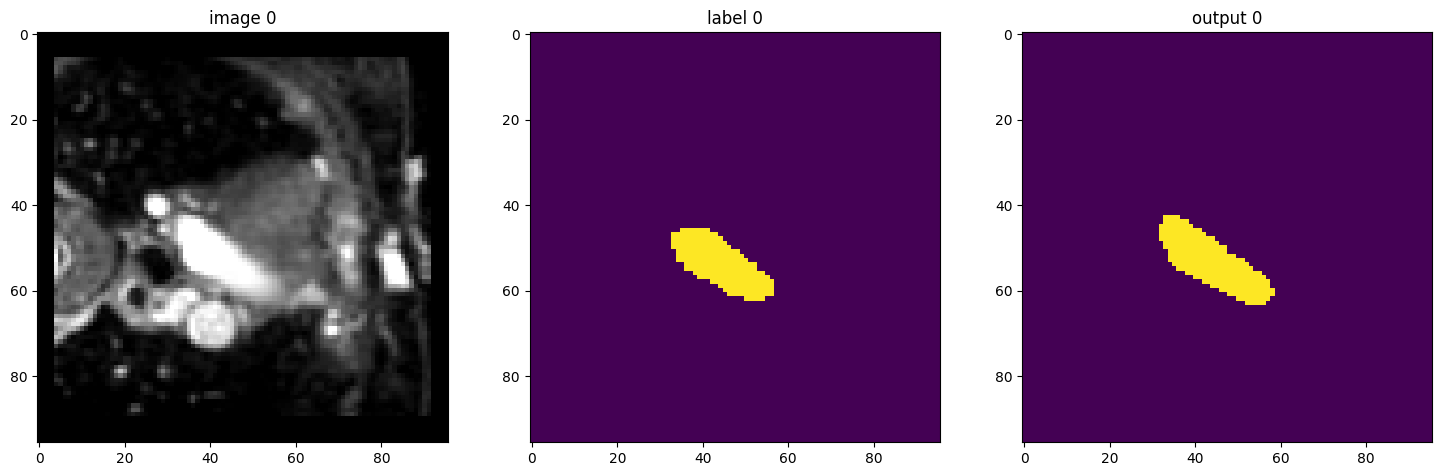

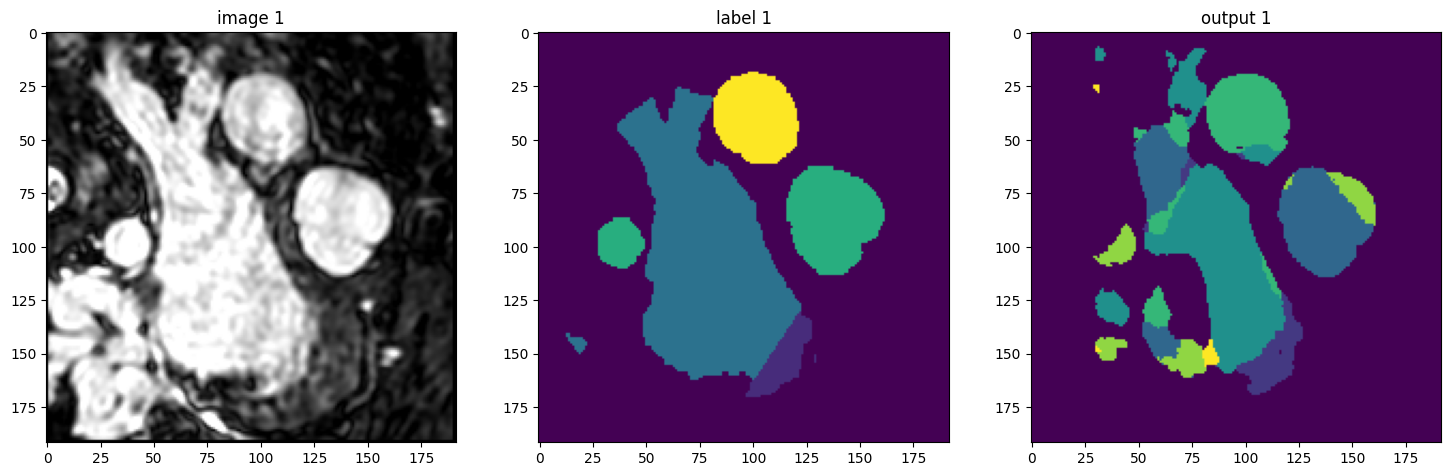

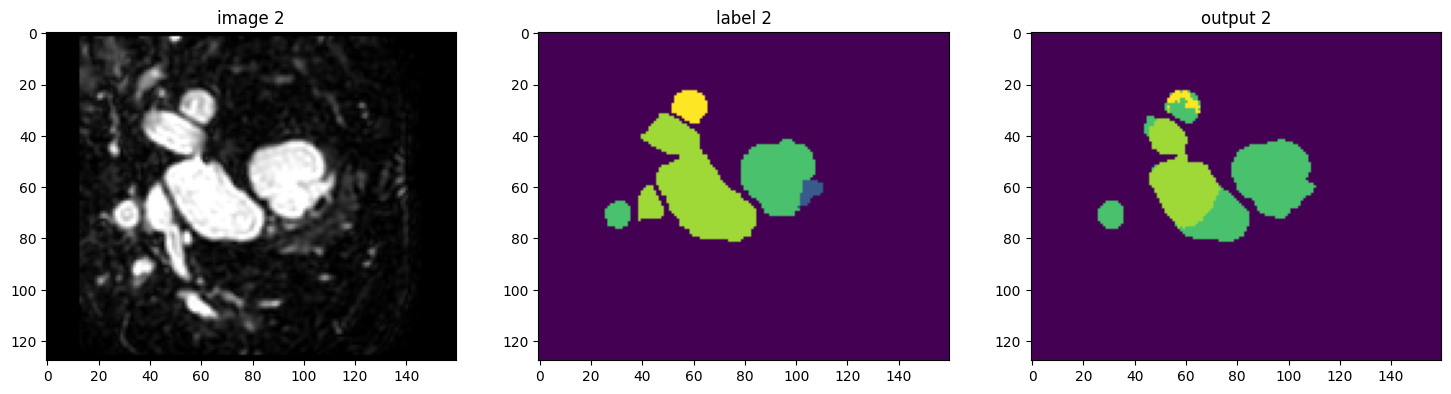

In [20]:
# Check best model output with the input image and label
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        # roi_size = (96, 96, 96)
        # sw_batch_size = 2
        #val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)
        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16):
            val_outputs = model(val_data["image"].to(device))
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :, 80], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, :, :, 80])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, 80])
        plt.show()
        if i == 2:
            break

In [21]:
# Disconnect and delete the current runtime
runtime.unassign()